<a href="https://colab.research.google.com/github/oxedanda/avcad_final_project/blob/main/notebooks/05_grassland_productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agricultural Data Analysis

## Permanent Grassland Area Analysis

### Evolution of Permanent Grassland and Pasture Area Plot

In [71]:
# Permanent Grassland Area Analysis
import pandas as pd
from IPython.display import display

# Load the permanent grasslands area data from GitHub
url_grasslands = "https://raw.githubusercontent.com/oxedanda/avcad_final_project/main/data/processed/permanent_grasslands_area_clean.csv"
grasslands = pd.read_csv(url_grasslands)

# Display the first few rows to understand the structure
print("Permanent Grasslands Data Head:")
display(grasslands.head())

# Sort by year to ensure correct chronological order
grasslands_sorted = grasslands.sort_values(by='year').reset_index(drop=True)

# Prepare data for the evolution table
years = grasslands_sorted['year'].tolist()
areas = grasslands_sorted['Total'].tolist()

# Initialize change lists with NaN (consistent with pandas default)
import numpy as np
changes_from_prev = [np.nan]  # First year has no previous change
changes_from_1989 = [np.nan]  # First year has no change from itself

area_1989 = areas[0]  # First year in sorted data is 1989

# Calculate percentage changes
for i in range(1, len(years)):
    current_area = areas[i]
    previous_area = areas[i-1]

    # Calculate change from previous year
    if previous_area != 0:
        pct_change_prev = ((current_area - previous_area) / previous_area) * 100
        changes_from_prev.append(f'{pct_change_prev:.2f}%')
    else:
        changes_from_prev.append('NaN')

    # Calculate change from 1989
    if area_1989 != 0:
        pct_change_1989 = ((current_area - area_1989) / area_1989) * 100
        changes_from_1989.append(f'{pct_change_1989:.2f}%')
    else:
        changes_from_1989.append('NaN')

# Create the detailed evolution table
grasslands_evolution_data = {
    'Year': years,
    'Area (ha)': [f'{area:,.0f}' for area in areas],
    'Change from Previous Year (%)': changes_from_prev,
    'Change from 1989 (%)': changes_from_1989
}

grasslands_evolution_table = pd.DataFrame(grasslands_evolution_data)

# Display the table
print("\nEvolution of Permanent Grassland and Pasture Area (1989–2019)")
display(grasslands_evolution_table)

# --- Save the table as an image ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=grasslands_evolution_table.values,
    colLabels=grasslands_evolution_table.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

ax.set_title(
    'Evolution of Permanent Grassland and Pasture Area (1989–2019)',
    fontsize=14,
    pad=20,
    fontweight='bold'
)

image_path = 'grasslands_evolution.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)
plt.close(fig)

print(f"Table image saved as: {image_path}")

Permanent Grasslands Data Head:


,year,geographic_location,code,Total,<0.5 ha,0.5 - <1 ha,1 - <2 ha,2 - <5 ha,5 - <20 ha,20 - <50 ha,50 - <100 ha,>= 100 ha
0,2019,Continente,1,2003795,4081,9103,21202,46055,117202,137036,195112,1474004
1,2009,Continente,1,1721587,4682,9282,19592,42963,104183,106250,127661,1306976
2,1999,Continente,1,1331033,6233,11087,22782,50696,111410,92054,111249,925523
3,1989,Continente,1,754825,7128,11360,23483,50412,75617,60658,64644,461523



Evolution of Permanent Grassland and Pasture Area (1989–2019)


,Year,Area (ha),Change from Previous Year (%),Change from 1989 (%)
0,1989,"754,825",NaN,NaN
1,1999,"1,331,033",76.34%,76.34%
2,2009,"1,721,587",29.34%,128.08%
3,2019,"2,003,795",16.39%,165.46%


Table image saved as: grasslands_evolution.png


### Table 3.7 — Evolution of Permanent Grassland and Pasture Area (1989–2019)

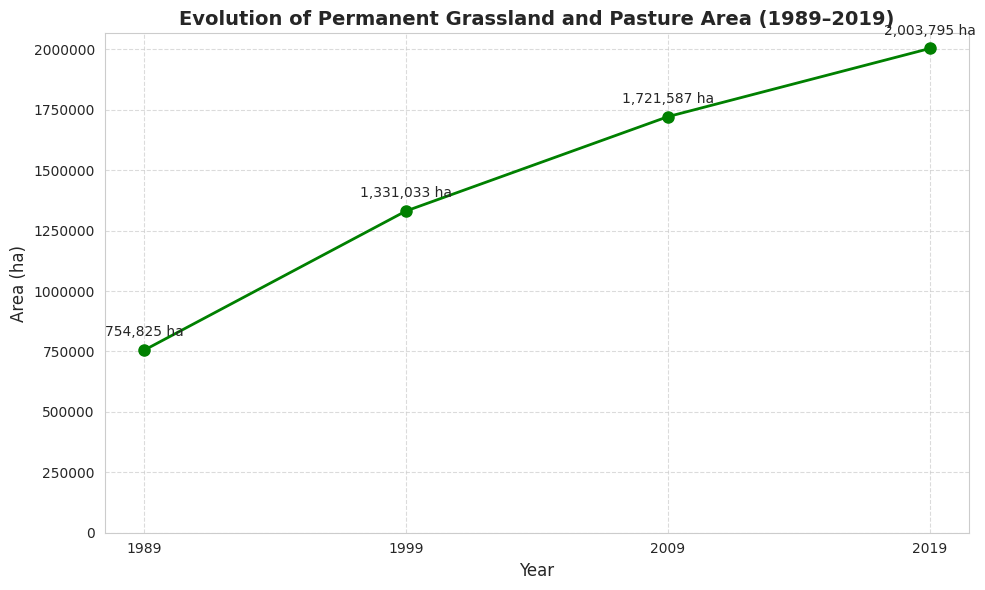

Figure saved as: grasslands_evolution.png


<Figure size 640x480 with 0 Axes>

In [72]:
# Figure: Evolution of Permanent Grassland and Pasture Area (1989-2019)
import matplotlib.pyplot as plt

# Ensure 'Area (ha)' is numeric for plotting
plot_data = grasslands_evolution_table.copy()
plot_data['Area (ha)'] = plot_data['Area (ha)'].str.replace(',', '').astype(int)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the line with markers
ax.plot(plot_data['Year'], plot_data['Area (ha)'],
        marker='o', linestyle='-', color='green', linewidth=2, markersize=8)

# Add title and labels
ax.set_title(
    'Evolution of Permanent Grassland and Pasture Area (1989–2019)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (ha)', fontsize=12)

# Format x-axis
ax.set_xticks(plot_data['Year'])

# Format y-axis
ax.ticklabel_format(style='plain', axis='y')
ax.set_ylim(bottom=0)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Annotate each point with its area value
for i, row in plot_data.iterrows():
    ax.annotate(
        f'{row["Area (ha)"]:,.0f} ha',
        (row['Year'], row['Area (ha)']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10
    )

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# Save the figure
image_path = 'grasslands_evolution.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)

# Close the figure to free memory
plt.close(fig)

print(f"Figure saved as: {image_path}")

## Crop Productivity Analysis

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import display

# Load data from GitHub
url_crop = "https://raw.githubusercontent.com/oxedanda/avcad_final_project/main/data/processed/crop_productivity_clean.csv"

# Load the data
productivity = pd.read_csv(url_crop)

# Sort by year
productivity = productivity.sort_values('year')

# Define crop columns (excluding metadata columns)
crop_cols = ['Cereals for grain', 'Main dried legumes', 'Potatoes',
             'Main crops for industry', 'Horticultural crops', 'Main fodder crops',
             'Main fresh fruits', 'Small berries', 'Main subtropical fruits',
             'Citrus fruits', 'Main nut fruits', 'Vineyards', 'Olive groves']

print("Data loaded successfully!")
display(productivity.head())

# Calculate percentage change (1989 to 2019)
pct_change = {}
for crop in crop_cols:
    val_1989 = productivity[crop].iloc[0]
    val_2019 = productivity[crop].iloc[-1]
    if pd.notna(val_1989) and pd.notna(val_2019) and val_1989 != 0:
        pct_change[crop] = ((val_2019 - val_1989) / val_1989 * 100)
    else:
        pct_change[crop] = None

# Create table with values and changes
table_data = {'Crop Category': crop_cols}
for year in productivity['year']:
    table_data[str(year)] = productivity[productivity['year'] == year][crop_cols].values.flatten().tolist()
table_data['Change (%)'] = [pct_change.get(crop, 'N/A') for crop in crop_cols]

table_39 = pd.DataFrame(table_data)

print("\nCrop Productivity by Category (1989–2019)")
display(table_39)

Data loaded successfully!


,year,geographic_location,code,Cereals for grain,Main dried legumes,Potatoes,Main crops for industry,Horticultural crops,Main fodder crops,Main fresh fruits,Small berries,Main subtropical fruits,Citrus fruits,Main nut fruits,Vineyards,Olive groves
3,1989,Continente,1,2013,560,11209,9303,NaN,NaN,6683,NaN,3773,7791,1325,4003,971
2,1999,Continente,1,2795,497,15142,20293,NaN,NaN,9585,NaN,11150,10043,822,4905,901
1,2009,Continente,1,3290,549,15566,35105,NaN,NaN,13726,NaN,17471,11924,580,4340,1229
0,2019,Continente,1,5160,797,22953,65754,NaN,28241.0,15451,10508.0,10690,19460,772,4948,2481



Crop Productivity by Category (1989–2019)


,Crop Category,1989,1999,2009,2019,Change (%)
0,Cereals for grain,2013.0,2795.0,3290.0,5160.0,156.333830
1,Main dried legumes,560.0,497.0,549.0,797.0,42.321429
2,Potatoes,11209.0,15142.0,15566.0,22953.0,104.772950
3,Main crops for industry,9303.0,20293.0,35105.0,65754.0,606.804257
4,Horticultural crops,NaN,NaN,NaN,NaN,NaN
5,Main fodder crops,NaN,NaN,NaN,28241.0,NaN
6,Main fresh fruits,6683.0,9585.0,13726.0,15451.0,131.198564
7,Small berries,NaN,NaN,NaN,10508.0,NaN
8,Main subtropical fruits,3773.0,11150.0,17471.0,10690.0,183.328916
9,Citrus fruits,7791.0,10043.0,11924.0,19460.0,149.775382


# Create the Productivity Change Ranking Table with Direction Column


In [65]:
# Productivity Change Ranking by Crop Category (1989-2019)
# Define crop columns
crop_cols = ['Cereals for grain', 'Main dried legumes', 'Potatoes',
             'Main crops for industry', 'Horticultural crops', 'Main fodder crops',
             'Main fresh fruits', 'Small berries', 'Main subtropical fruits',
             'Citrus fruits', 'Main nut fruits', 'Vineyards', 'Olive groves']

# Calculate percentage change (1989 to 2019)
pct_change = {}
for crop in crop_cols:
    val_1989 = productivity[crop].iloc[0]
    val_2019 = productivity[crop].iloc[-1]
    if pd.notna(val_1989) and pd.notna(val_2019) and val_1989 != 0:
        pct_change[crop] = ((val_2019 - val_1989) / val_1989 * 100)
    else:
        pct_change[crop] = None

# Define function to determine direction
def get_direction(pct):
    if pct is None or pd.isna(pct):
        return 'N/A'
    elif pct >= 100:
        return '↑ Strong growth'
    elif pct >= 50:
        return '↑ Significant growth'
    elif pct >= 20:
        return '↑ Moderate growth'
    elif pct >= 0:
        return '↑ Modest growth'
    elif pct >= -20:
        return '↓ Slight decline'
    elif pct >= -50:
        return '↓ Moderate decline'
    else:
        return '↓ Sharp decline'

# Create ranking table
ranking_data = {
    'Crop Category': crop_cols,
    'Change (%)': [pct_change.get(crop, 'N/A') for crop in crop_cols],
    'Direction': [get_direction(pct_change.get(crop, None)) for crop in crop_cols]
}

# Convert to DataFrame and sort
table_ranking = pd.DataFrame(ranking_data)
table_ranking = table_ranking.sort_values(by='Change (%)', ascending=False).reset_index(drop=True)

# Format the Change (%) column
table_ranking['Change (%)'] = table_ranking['Change (%)'].apply(
    lambda x: f'{x:.2f}%' if isinstance(x, (int, float)) and pd.notna(x) else 'N/A'
)

# Add Rank column
table_ranking.insert(0, 'Rank', range(1, len(table_ranking) + 1))

# Display the ranking table
print("Productivity Change Ranking by Crop Category (1989–2019)")
display(table_ranking)

Productivity Change Ranking by Crop Category (1989–2019)


,Rank,Crop Category,Change (%),Direction
0,1,Main crops for industry,606.80%,↑ Strong growth
1,2,Main subtropical fruits,183.33%,↑ Strong growth
2,3,Cereals for grain,156.33%,↑ Strong growth
3,4,Olive groves,155.51%,↑ Strong growth
4,5,Citrus fruits,149.78%,↑ Strong growth
5,6,Main fresh fruits,131.20%,↑ Strong growth
6,7,Potatoes,104.77%,↑ Strong growth
7,8,Main dried legumes,42.32%,↑ Moderate growth
8,9,Vineyards,23.61%,↑ Moderate growth
9,10,Main nut fruits,-41.74%,↓ Moderate decline


### User Provided Productivity Change Ranking Table

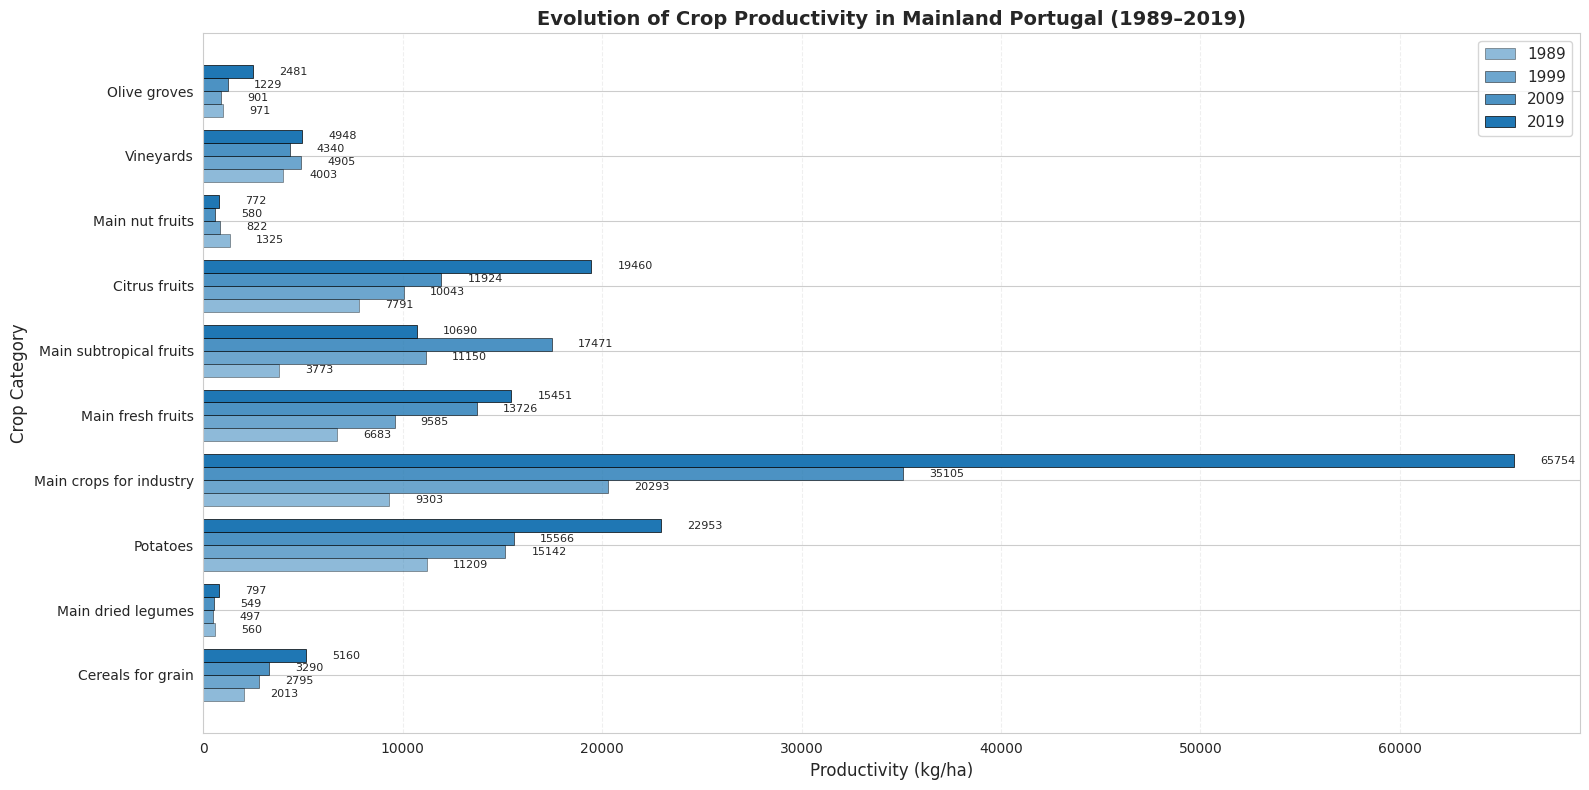

Figure saved as: crop_productivity_evolution.png


<Figure size 640x480 with 0 Axes>

In [64]:
# --- Crop Productivity Evolution (1989-2019) ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style
sns.set_style('whitegrid')

# Define all crop columns with valid data (excluding N/A categories)
crops = [
    'Cereals for grain',
    'Main dried legumes',
    'Potatoes',
    'Main crops for industry',
    'Main fresh fruits',
    'Main subtropical fruits',
    'Citrus fruits',
    'Main nut fruits',
    'Vineyards',
    'Olive groves'
]

# Years to display
years = [1989, 1999, 2009, 2019]

# Prepare data
crop_labels = []
values_by_year = {year: [] for year in years}

for crop in crops:
    crop_labels.append(crop)
    for year in years:
        val = productivity[productivity['year'] == year][crop].values[0]
        values_by_year[year].append(val if pd.notna(val) else 0)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(16, 8))

# Set the bar positions (horizontal)
y = np.arange(len(crop_labels))
height = 0.2
multiplier = 0

# Colors for each year (same color, different opacity)
colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4']
alphas = [0.5, 0.65, 0.8, 1.0]

# Create horizontal bars for each year
for i, year in enumerate(years):
    offset = height * multiplier
    bars = ax.barh(y + offset, values_by_year[year], height,
                   label=f'{year}', color=colors[i],
                   edgecolor='black', linewidth=0.5, alpha=alphas[i])
    multiplier += 1

# Add value labels on the bars
for i in range(len(crop_labels)):
    for j, year in enumerate(years):
        val = values_by_year[year][i]
        if val > 0:
            ax.text(val + max(max(values_by_year[2019]) * 0.02, 100),
                    i + height * j,
                    f'{val:.0f}', ha='left', va='center', fontsize=8)

# Customize the plot
ax.set_title(
    'Evolution of Crop Productivity in Mainland Portugal (1989–2019)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Productivity (kg/ha)', fontsize=12)
ax.set_ylabel('Crop Category', fontsize=12)

# Set y-ticks and labels
ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(crop_labels, fontsize=10)

# Add legend
ax.legend(fontsize=11)

# Format x-axis
ax.ticklabel_format(style='plain', axis='x')
ax.set_xlim(left=0)

# Add grid
ax.grid(True, linestyle='--', alpha=0.3, axis='x')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# Save the figure
plt.savefig('crop_productivity_evolution.png', dpi=300, bbox_inches='tight')

print("Figure saved as: crop_productivity_evolution.png")